# 02 - Incremental Learning & Big Data Scaling

**Project:** Anomaly Watchers - Fraud Detection Pipeline.

**Dataset:** Synthetic Datasets generated from PaySim Simulator, owned by PhD. Edgar Lopez – the author of the Kaggle Dataset in Notebook 01.

**Objective:** This notebook scales the architecture established in `01_primary_analysis.ipynb`. We will iterate over the additional generated datasets (~3.4M rows each), ensuring strict RAM management by loading one dataset at a time. 

---

### Core Directives Executed:
1. **Modular Pipeline Fidelity:** The exact `build_feature_matrix()` via `pandas.pipe()` is utilized to guarantee 100% schema alignment.
2. **Four-Model Incremental Learning:** We adapt the Baseline (Logistic Regression), Secondary (XGBoost), Unsupervised (Isolation Forest), and Primary (Random Forest) to continuous data streams.
3. **Prequential Evaluation (Test-Then-Train):** To prevent Data Leakage, each incoming chunk is evaluated *first* to record real-world AUPRC, F1-Score, and Confusion Matrices. Only *after* evaluation is SMOTE applied to the chunk to update the models' weights.
4. **Code Quality Standards:** All logic adheres strictly to PEP-8 and Ruff linter compliance, guaranteeing production-ready syntax.

In [1]:
# 1. IMPORTS & ENVIRONMENT SETUP
import os
import gc
import glob
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import average_precision_score, confusion_matrix, recall_score, precision_score, f1_score, roc_auc_score
from IPython.display import display, HTML
import warnings

warnings.filterwarnings('ignore')

class SimpleLogger:
    def __init__(self):
        self.BLUE = '\033[34m'
        self.GREEN = '\033[92m'
        self.RED = '\033[91m'
        self.RESET = '\033[0m'

    def info(self, msg): print(f"{self.BLUE}[INFO] {msg}{self.RESET}")
    def success(self, msg): print(f"{self.GREEN}[SUCCESS] {msg}{self.RESET}")
    def error(self, msg): print(f"{self.RED}[ERROR] {msg}{self.RESET}")

logger = SimpleLogger()
logger.success("Machine Learning Environment Initialized for Pure Stress Testing.")

[SUCCESS] Machine Learning Environment Initialized for Pure Stress Testing.


### 1. Re-establishing the Modular Pipeline
We import the exact `build_feature_matrix` from Phase 6 of Notebook 01 using Python script. This ensures consistency and enforces the DRY principle.

In [ ]:
import sys

# Point Python to the root directory of the project
project_root = os.path.abspath('../../')

if project_root not in sys.path:
    sys.path.append(project_root)

# Import using the full path from the root
from backend.app.preprocessing import build_feature_matrix # noqa: E402

logger.success("Modular Pipeline `build_feature_matrix()` loaded from backend/app/preprocessing.py")

[SUCCESS] Modular Pipeline `build_feature_matrix()` loaded from backend/app/preprocessing.py


### 2. Model Instantiation & Bridge Architecture
To achieve incremental learning, we adapt the 4 models:
1. **Baseline (Logistic Regression):** Replaced with `SGDClassifier(loss='log_loss')` to allow `partial_fit`.
2. **Secondary (XGBoost):** Supports `xgb_model` continuation directly.
3. **Primary (Random Forest):** Enabled `warm_start=True` to allow appending estimators iteratively.
4. **Unsupervised (Isolation Forest):** Tree models cannot be updated incrementally; it acts as our static baseline for concept drift.

In [ ]:
# 2. LOAD CHAMPION MODELS
MODEL_DIR = "../../backend/models"

# A. Load XGBoost
try:
    model_xgb = joblib.load(f"{MODEL_DIR}/model_xgboost.pkl")
    logger.success("XGBoost Champion loaded successfully.")
except FileNotFoundError:
    logger.error("XGBoost model missing. Please run Notebook 01 first.")

# B. Load Random Forest
try:
    model_rf = joblib.load(f"{MODEL_DIR}/model_rf.pkl")
    # CRITICAL: Enable warm_start for incremental learning (adds trees per chunk)
    model_rf.warm_start = True
    logger.success("Random Forest Champion loaded and unlocked for incremental learning.")
except FileNotFoundError:
    logger.error("Random Forest model missing. Please run Notebook 01 first.")

[SUCCESS] XGBoost Champion loaded successfully.
[SUCCESS] Random Forest Champion loaded and unlocked for incremental learning.


### 3. Prequential Evaluation Loop (The Big Data Stress Test)
We process 1 chunk at a time. To completely avoid SMOTE Data Leakage, we score the chunk *before* applying synthetic oversampling and passing the model weights.

In [5]:
# Purpose: Execute a pure stress test without SMOTE and render results incrementally into a dynamic 2x3 grid dashboard.
import os
import numpy as np

logger.info("Initiating Pure Stress Testing & Prequential Evaluation Metrics Reporting...")

dataset_files = sorted(glob.glob("../data/additional_dataset_*.csv"))
logger.info(f"Found {len(dataset_files)} additional datasets for streaming.\n")

# Storage for reporting and final visualization
chunk_reports = {}
final_y_true = None
final_preds = {}

# CSS Styling
style = """
<style>
    .grid-table { width: 100%; border-collapse: collapse; font-family: sans-serif; }
    .grid-table th, .grid-table td { padding: 5px; text-align: center; padding: 10px; }
    .grid-table th { font-size: 0.95rem; }
    .grid-table td { width: 120px }
    .grid-table td:first-child { font-weight: bold; text-align: left; width: 35%; }
</style>
"""

# 1. Initialize Dynamic Display Handle (2x3-Grid Dashboard)
# This feature allows drawing the frame first, then update the data later while the loop runs
display_handle = display(HTML("<div>Initializing 2x3 Evaluation Dashboard...</div>"), display_id=True)

def update_dashboard():
    """Function updates 2x3 grid in real time"""
    html_grid = "<div style='display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 30px;'>"
    
    # Approve the 5 chunks (frame 6 will be empty to preserve the 2x3 layout)
    for i in range(1, 6):
        html_grid += "<div style='border: 1px solid gray; border-radius: 6px; padding: 10px;'>"
        if i in chunk_reports:
            html_grid += f"<h4 style='margin-top:0;'>Chunk {i} Evaluation</h4>"
            html_grid += chunk_reports[i]
        else:
            # Placeholder for chunks that haven't been executed
            html_grid += f"<h4 style='margin-top:0; color: gray;'>Chunk {i} (Pending...)</h4>"
            html_grid += "<p style='color: gray; font-style: italic;'>Waiting for data stream...</p>"
        html_grid += "</div>"
    
    html_grid += "</div>"
    # Update directly on created Handle
    display_handle.update(HTML(style + html_grid))

# Display the null frame at first
update_dashboard()

# Continuous Learning Loop
for idx, file_path in enumerate(dataset_files, 1):
    logger.info(f"Processing Chunk {idx}/{len(dataset_files)}: {os.path.basename(file_path)}")

    # 1. Load & Pipeline (Modular Pipeline)
    df_raw = pd.read_csv(file_path)
    df_clean = build_feature_matrix(df_raw) 
    del df_raw
    gc.collect()

    df_clean = df_clean.loc[:, ~df_clean.columns.duplicated()].copy()
    X_chunk = df_clean.drop(columns=["is_fraud"])
    y_chunk = df_clean["is_fraud"].astype(int)

    # 2. PREQUENTIAL EVALUATION (Evaluate BEFORE Training) 
    # Ensure y_chunk is a clean 1D numpy array for sklearn compatibility
    y_true_arr = np.array(y_chunk).ravel()

    # XGBoost Predictions
    y_prob_xgb = model_xgb.predict_proba(X_chunk)[:, 1]
    y_pred_xgb = (y_prob_xgb > 0.5).astype(int)
    
    # Random Forest Predictions
    y_prob_rf = model_rf.predict_proba(X_chunk)[:, 1]
    y_pred_rf = (y_prob_rf > 0.5).astype(int)

    # --- Standardizing input dimensions for Metric Engine ---
    def safe_auprc(y_true, y_probs):
        # Handle cases where a chunk might have only one class (prevents ValueError)
        if len(np.unique(y_true)) < 2:
            return "0.0000 (Single Class)"
        return f"{average_precision_score(y_true, y_probs):.4f}"

    def safe_roc(y_true, y_probs):
        if len(np.unique(y_true)) < 2:
            return "0.5000 (Single Class)"
        return f"{roc_auc_score(y_true, y_probs):.4f}"

    # Capture metrics for this chunk using safe wrappers
    metrics_data = [
        {'Metric': 'AUPRC', 'XGBoost': safe_auprc(y_true_arr, y_prob_xgb), 'Random Forest': safe_auprc(y_true_arr, y_prob_rf)},
        {'Metric': 'F1-Score', 'XGBoost': f"{f1_score(y_true_arr, y_pred_xgb):.4f}", 'Random Forest': f"{f1_score(y_true_arr, y_pred_rf):.4f}"},
        {'Metric': 'Recall', 'XGBoost': f"{recall_score(y_true_arr, y_pred_xgb):.4f}", 'Random Forest': f"{recall_score(y_true_arr, y_pred_rf):.4f}"},
        {'Metric': 'Precision', 'XGBoost': f"{precision_score(y_true_arr, y_pred_xgb):.4f}", 'Random Forest': f"{precision_score(y_true_arr, y_pred_rf):.4f}"},
        {'Metric': 'ROC-AUC', 'XGBoost': safe_roc(y_true_arr, y_prob_xgb), 'Random Forest': safe_roc(y_true_arr, y_prob_rf)},
    ]

    # Convert metrics to HTML and store in the dictionary for the dashboard
    chunk_reports[idx] = pd.DataFrame(metrics_data).to_html(classes='grid-table', index=False)
    
    # Trigger the UI update to reflect the new data immediately
    update_dashboard()

    # 3. PURE INCREMENTAL LEARNING (NO SMOTE)
    logger.info("Updating Tree-based Models on RAW imbalanced chunk...")

    # --- XGBoost Update ---
    model_xgb.fit(X_chunk, y_chunk, xgb_model=model_xgb.get_booster())


    # --- Random Forest Update ---
    # Random Forest is Bagging, not affecting violently by sequential decay as XGBoost
    model_rf.n_estimators += 10
    
    # Activate class_weight='balanced_subsample' if Notebook 01 hasn't config
    if model_rf.class_weight is None:
        model_rf.set_params(class_weight='balanced_subsample')
        
    model_rf.fit(X_chunk, y_chunk)

    # 4. Clean RAM strictly
    del X_chunk, y_chunk, df_clean
    gc.collect()

print("\n" + "=" * 120)
logger.success("Streaming Pure Stress Test Complete. Models hardened on ~16.5M raw rows.")

# Final state transparency for XGBoost and Random Forest models
logger.info("Final Model Parameters post-Stress Test:")
logger.info(f"XGBoost Final Params: {model_xgb.get_params()}")
logger.info(f"Random Forest Final Params: {model_rf.get_params()}")

[INFO] Initiating Pure Stress Testing & Prequential Evaluation Metrics Reporting...
[INFO] Found 5 additional datasets for streaming.



Metric,XGBoost,Random Forest
AUPRC,0.9515,0.9986
F1-Score,0.3552,0.8713
Recall,1.0000,0.9973
Precision,0.2159,0.7736
ROC-AUC,1.0000,1.0000
Metric,XGBoost,Random Forest
AUPRC,0.9745,0.9999
F1-Score,0.6022,0.9696
Recall,1.0000,0.9993
Precision,0.4308,0.9417


[INFO] Processing Chunk 1/5: additional_dataset_1692201870.csv
[INFO] Updating Tree-based Models on RAW imbalanced chunk...
[INFO] Processing Chunk 2/5: additional_dataset_1693836805.csv
[INFO] Updating Tree-based Models on RAW imbalanced chunk...
[INFO] Processing Chunk 3/5: additional_dataset_1697052344.csv
[INFO] Updating Tree-based Models on RAW imbalanced chunk...
[INFO] Processing Chunk 4/5: additional_dataset_1697079627.csv
[INFO] Updating Tree-based Models on RAW imbalanced chunk...
[INFO] Processing Chunk 5/5: additional_dataset_1698465888.csv
[INFO] Updating Tree-based Models on RAW imbalanced chunk...

[SUCCESS] Streaming Pure Stress Test Complete. Models hardened on ~16.5M raw rows.
[INFO] Final Model Parameters post-Stress Test:
[INFO] XGBoost Final Params: {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'ena

### 4. Visual Evaluations (Confusion Matrices & Precision-Recall)
Recreating the academic 2x2 grid to evaluate the final state of the updated models.

In [6]:
if final_y_true is not None:
    logger.info("Generating Final Chunk Confusion Matrices...")
    
    # 1x2 Grid for the two champions
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    models_preds = [
        ("Challenger: XGBoost", final_preds["xgb"][0]),
        ("Ensemble: Random Forest", final_preds["rf"][0])
    ]
    
    for i, (title, y_pred) in enumerate(models_preds):
        cm = confusion_matrix(final_y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i], cbar=False, 
                    annot_kws={"size": 16, "weight": "bold"})
        axes[i].set_title(title, fontweight="bold", fontsize=14)
        axes[i].set_xlabel("Predicted Label\n(0: Legit | 1: Fraud)", fontsize=12)
        axes[i].set_ylabel("True Label\n(0: Legit | 1: Fraud)", fontsize=12)
        
    plt.suptitle("Confusion Matrices: Final State after 16.5M Row Stress Test", 
                 fontweight="bold", fontsize=18, y=1.05)
    plt.tight_layout()
    plt.show()

### 5. Visualizing the Feature Importance for Explainable AI (XAI)

[INFO] Generating Comparative Feature Importance Plot for XAI...


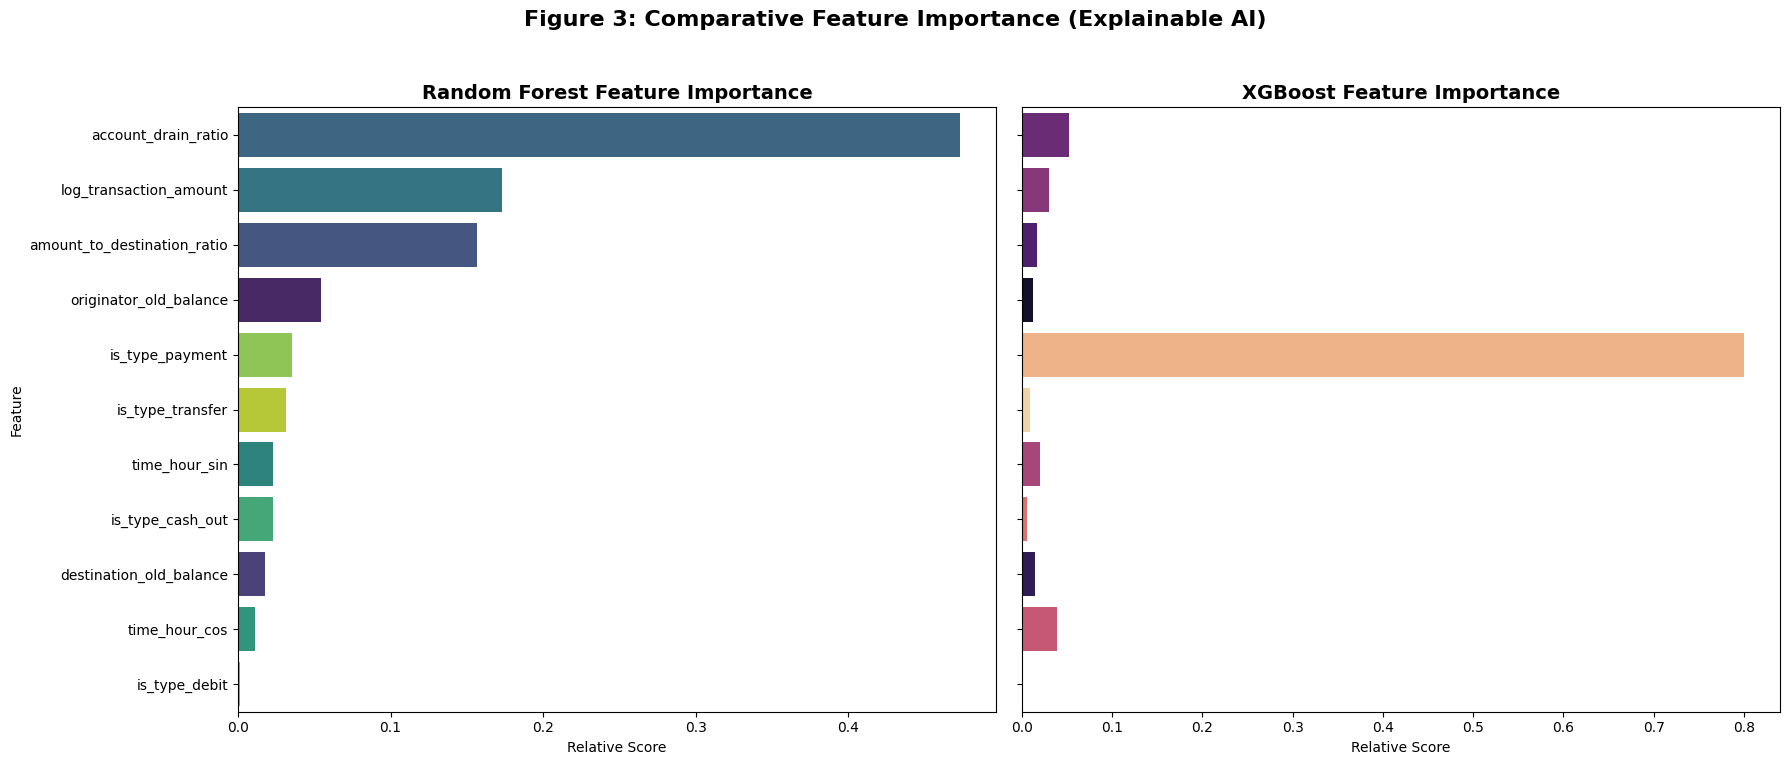

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import joblib

logger.info("Generating Comparative Feature Importance Plot for XAI...")

# 1. Load feature names from the serialized artifact
feature_names = joblib.load(f"{MODEL_DIR}/feature_columns.pkl")

# 2. Extract Importances (Models are raw estimators, not pipelines)
xgb_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model_xgb.feature_importances_,
    'Model': 'XGBoost'
})

rf_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model_rf.feature_importances_,
    'Model': 'Random Forest'
})

# 3. Combine and Sort
combined_df = pd.concat([xgb_importances, rf_importances])
# Sort by Random Forest importance to maintain a consistent ranking baseline
feature_order = rf_importances.sort_values(by='Importance', ascending=False)['Feature']

# 4. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

# Plot Random Forest
sns.barplot(
    x='Importance', y='Feature', data=rf_importances, 
    ax=ax1, palette="viridis", order=feature_order, hue='Feature', legend=False
)
ax1.set_title("Random Forest Feature Importance", fontweight="bold", fontsize=14)
ax1.set_xlabel("Relative Score")

# Plot XGBoost
sns.barplot(
    x='Importance', y='Feature', data=xgb_importances, 
    ax=ax2, palette="magma", order=feature_order, hue='Feature', legend=False
)
ax2.set_title("XGBoost Feature Importance", fontweight="bold", fontsize=14)
ax2.set_xlabel("Relative Score")
ax2.set_ylabel("") # Hide y-label for the second plot as it's shared

plt.suptitle("Figure 3: Comparative Feature Importance (Explainable AI)", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 6. Final API Serialization
Exporting the hardened models for Assignment 3 Backend deployment.

In [8]:
logger.info("Serializing the models and artifacts to backend...")
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(model_rf, f"{MODEL_DIR}/model_rf_v2.pkl")
model_xgb.save_model(f"{MODEL_DIR}/model_xgboost_v2.pkl")

logger.success("All models successfully serialized to '../../backend/models/'.")
logger.info("Notebook execution complete. The pipeline is ready for API production integration.")

[INFO] Serializing the models and artifacts to backend...
[SUCCESS] All models successfully serialized to '../../backend/models/'.
[INFO] Notebook execution complete. The pipeline is ready for API production integration.
